# Signal with Mediation: SHAP, Causal SHAP, and PCI

Imagine a feature $X$ that influences an outcome $Y$ only *through* an
intermediate variable $M$: the mediation chain $X \to M \to Y$. $X$ never touches
$Y$ directly — it acts only by moving $M$, which in turn moves $Y$. This tiny
three-variable world turns out to be a sharp test for explanation methods,
because the honest answer to "what caused $Y$?" has to respect that asymmetry:
$M$ is the *direct* cause of $Y$, while $X$ is only an *indirect* one, and a
trustworthy method should rank $M$ differently than $X$ without our having to tell it so.

The trouble is that the most popular attribution methods don't. Methods built on
statistical association tend to hand $X$ and $M$ the *same* credit for $Y$ — they
cannot see that $X$'s influence is second-hand — and they will even pay a
variable for an outcome it merely *predicts* rather than causes (crediting $Y$
for $X$, say, only because the two are correlated). This notebook works the whole
comparison out in closed form on a Gaussian chain, so every number is exact and
checkable, and shows precisely where each method succeeds, where it fails, and
how **Probabilistic Causal Impact (PCI)** repairs the failures.

Three methods sit side by side throughout. **Plain SHAP** distributes a
prediction fairly among the features using *observational* conditional
expectations. **Causal SHAP** keeps the same fairness machinery but values
features through *interventions* ($\mathrm{do}$), which mends one leak but not the
rest. And **PCI**, our method, abandons the prediction-splitting frame entirely
and asks a counterfactual question instead: how far does the *realized* outcome
move when we re-roll a suspect (its *necessity*) versus pin it in place (its
*sufficiency*), optionally holding a third **witness** variable fixed to block an
indirect path?

Four terms recur, so it is worth fixing them once. The **suspect** is the
candidate cause whose responsibility we are scoring. The **necessity world**
re-rolls that suspect to a random alternative and re-runs the model — *would the
outcome have changed without the suspect's actual value?* The **sufficiency
world** instead pins the suspect at its factual value and re-runs with fresh
noise — *does the suspect on its own keep reproducing the outcome?* And a
**witness** is a third variable we hold fixed while testing the suspect; pinning
$M$, for instance, severs the indirect route $X \to M \to Y$, which is exactly
the lever that lets PCI tell a direct cause from an indirect one.

You can read the notebook at three depths: the prose alone tells the whole story,
the markdown tables give the numbers, and the code cells show how each quantity
is computed for anyone who wants the mechanism. The one result to watch for is
**D-MXY** — does a method rank the direct cause $M$ above the indirect cause $X$
for $Y$? Both SHAP variants *tie* here and so fail it; PCI separates them on
structure alone, and adding the mediator as a witness widens a fragile margin
into a robust one.

**Relation to the paper.** This notebook reproduces every number in the *Signal
with Mediation* example and uses the desiderata names (D-XY, D-MY, D-MXY, …) 
exactly as stated there.

## Outline

1. Model and setup, and the desiderata we grade against
2. Optimal predictors (the models SHAP explains)
3. Plain SHAP
4. Causal SHAP
5. PCI without witnesses
6. PCI with witnesses
7. The desiderata scorecard and what it shows
8. General analytic forms for any instance
9. Instance 2: the baseline, where SHAP collapses to zero
10. Instance 3: a counter-responsible $X$
11. Three-instance comparison and takeaways

## 1. Model and setup

The generative model is a linear chain $X \to M \to Y$ with additive Gaussian
noise: $X$ emits a signal, $M$ relays it with some noise, and $Y$ is the noisy
final outcome. Because everything is jointly Gaussian, all conditional
expectations are exactly linear and every quantity below has a closed form — no
approximations are needed, which is why this example is a clean testbed.

| Variable | Distribution | Reading |
|---|---|---|
| $X$ | $\mathcal{N}(0.5,\; 0.25)$ | exogenous root cause |
| $M$ | $X + \varepsilon_M$, $\varepsilon_M \sim \mathcal{N}(0,\, 0.1)$ | mediator |
| $Y$ | $M + \varepsilon_Y$, $\varepsilon_Y \sim \mathcal{N}(0,\, 0.1)$ | outcome |

Note the key structural fact we will lean on repeatedly: **$X$ reaches $Y$ only
through $M$** (the path $X \to M \to Y$), whereas **$M$ acts on $Y$ directly**.
A method that respects causal structure should be able to tell these two roles
apart.

The chain $X \to M \to Y$ is drawn below; the mediator $M$ and the outcome $Y$ are highlighted.


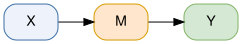

In [1]:
# Causal DAG for the signal-with-mediation model: the chain X -> M -> Y. The
# mediator M (orange) carries X's influence to the outcome Y (green); X reaches
# Y only through M. Falls back to a text edge-list if the graphviz binary is
# absent.
from IPython.display import display

try:
    from graphviz import Digraph

    g = Digraph("signal", graph_attr={"rankdir": "LR"})
    g.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="Helvetica",
        color="#3b6ea5",
        fillcolor="#eef3fb",
    )
    g.node("X")
    g.node("M", fillcolor="#ffe6cc", color="#d79b00")  # mediator / witness
    g.node("Y", fillcolor="#d5e8d4", color="#82b366")  # outcome
    g.edge("X", "M")
    g.edge("M", "Y")
    display(g)
except Exception as exc:  # pragma: no cover - graphviz binary missing
    print(f"(graphviz unavailable: {exc}; showing edge list instead)\n")
    print("  X → M")
    print("  M → Y")

**Factual instance:** $x^\star = m^\star = y^\star = 1$ (Instance 1). Every
variable sits one above its mean of $0.5$, so every prediction is non-trivial
and all three methods return non-zero values — the cleanest case to compare
them on. (Sections 9–11 revisit two further instances that stress the methods.)

**Contrast function.** PCI scores a suspect $A$ by comparing two counterfactual
worlds against the realized outcome $y^\star$, using
$$\mathrm{ci}(y^s, y^n, y^\star) = \underbrace{|y^n - y^\star|}_{\text{necessity}} - \underbrace{|y^s - y^\star|}_{\text{sufficiency}}.$$
The **necessity** world replaces the suspect with a random redraw $A' \sim P(A)$
and runs the model forward: a large $|y^n - y^\star|$ means the outcome *needed*
the suspect's actual value. The **sufficiency** world restores the suspect to
$a^\star$ and runs forward with fresh noise: a small $|y^s - y^\star|$ means the
suspect *on its own* reliably reproduces the outcome. Subtracting the two rewards a suspect that is at once *needed* and *enough*: $\mathrm{ci}$ is large precisely when re-rolling the suspect throws the outcome off (a large necessity term) while pinning it holds the outcome in place (a small sufficiency term) — the two hallmarks of a genuine cause. Both worlds draw fresh
exogenous noise from $P_{\mathbf{U}}$, so the comparison isolates the suspect's
causal role rather than a single noise realization. A higher $\mathrm{ci}$ means
*more* causal responsibility.

### The desiderata: what a correct attribution must say here

Before computing anything we fix the *target* — the conditions a good attribution
method should satisfy on this chain. We grade all four methods (plain SHAP,
causal SHAP, PCI without and with a witness) against the same seven
**desiderata**, named exactly as in the paper. They refer to a generic
responsibility score $R(V \rightsquigarrow B)$ — a placeholder for whatever
number a method assigns to variable $V$ for target $B$ — and, since SHAP can be
signed, the conditions are stated on magnitudes $\lvert R\rvert$.

| Name | In words | Condition |
|---|---|---|
| **D-XY** | $X$ is an (indirect) cause of $Y$ | $\lvert R(X\rightsquigarrow Y)\rvert > 0$ |
| **D-MY** | $M$ is a (direct) cause of $Y$ | $\lvert R(M\rightsquigarrow Y)\rvert > 0$ |
| **D-XM** | $X$ is a cause of $M$ | $\lvert R(X\rightsquigarrow M)\rvert > 0$ |
| **D-YX** | $Y$ is *not* a cause of $X$ | $R(Y\rightsquigarrow X) = 0$ |
| **D-YM** | $Y$ is *not* a cause of $M$ | $R(Y\rightsquigarrow M) = 0$ |
| **D-MX** | $M$ is *not* a cause of $X$ | $R(M\rightsquigarrow X) = 0$ |
| **D-MXY** | the direct cause outranks the indirect one | $\lvert R(M\rightsquigarrow Y)\rvert > \lvert R(X\rightsquigarrow Y)\rvert$ |

Three groups, three jobs:

- **Positive** (D-XY, D-MY, D-XM): the method must *acknowledge* a genuine causal
  link — a non-zero score (a negative SHAP value still counts).
- **Zero** (D-YX, D-YM, D-MX): the method must *not* send credit backwards,
  against the arrows of the chain.
- **Discriminating** (D-MXY): the headline test — because $X$ reaches $Y$ only
  through $M$, the *direct* cause $M$ should rank strictly above the *indirect*
  cause $X$. This is the one that separates the methods: both SHAP variants tie,
  PCI breaks the tie, and a witness widens the margin.

The full pass/fail audit is assembled in §7; **PCI passes all seven, while both
SHAP variants fail the three Zero desiderata and tie on D-MXY.**


In [2]:
import os

import numpy as np
from scipy.stats import norm

# Smoke-test mode is triggered by ``CI=1``. It shrinks the Monte Carlo sample
# size used to cross-check the closed-form PCI values. Closed-form numbers in
# the paper are unaffected; only the ``mc_*`` cross-checks get noisier.
smoke_test = "CI" in os.environ

rng = np.random.default_rng(42)
N = 10_000 if smoke_test else 2_000_000

mu_X, var_X = 0.5, 0.25
var_eM = 0.1
var_eY = 0.1
var_M = var_X + var_eM  # 0.35
var_Y = var_M + var_eY  # 0.45
cov_XM = var_X  # 0.25
cov_XY = var_X  # 0.25
cov_MY = var_M  # 0.35
mu_M = mu_X
mu_Y = mu_X
x_star, m_star, y_star = 1.0, 1.0, 1.0

print(f"Var(X)={var_X}, Var(M)={var_M}, Var(Y)={var_Y}")
print(f"Cov(X,M)={cov_XM}, Cov(X,Y)={cov_XY}, Cov(M,Y)={cov_MY}")

Var(X)=0.25, Var(M)=0.35, Var(Y)=0.44999999999999996
Cov(X,M)=0.25, Cov(X,Y)=0.25, Cov(M,Y)=0.35


## 2. Optimal predictors

SHAP explains a *model*, so we first need a predictor for each target. We use
the optimal (squared-loss) predictor for each variable given the other two,
which in this Gaussian model is just the conditional expectation and is exactly
linear. We will explain three different targets in turn — $Y$, $M$, and $X$ —
because the desiderata ask about responsibility flowing in *both* causal
directions (e.g. does $Y$ wrongly get credit for $X$?).

- $f_Y(x, m) = m$ is exact: given $M$, the noise $\varepsilon_Y$ is all that
  separates $M$ from $Y$, and $X$ adds nothing once $M$ is known.
- $f_M(x, y)$ and $f_X(m, y)$ are the linear least-squares predictors read off
  the joint Gaussian. Note $f_M$ uses $Y$ as an input even though $Y$ is
  *downstream* of $M$ — purely because $Y$ is statistically predictive of $M$.
  This is exactly the kind of backward dependence that will trip SHAP up later.

The cell below confirms the coefficients match the closed forms derived in
Appendix B ($f_M = 0.5X + 0.5Y$ and $f_X = 0.5 + \tfrac{5}{7}(M - 0.5)$).

In [3]:
def f_Y(x, m):
    return m


Sigma_XY = np.array([[var_X, cov_XY], [cov_XY, var_Y]])
coeff_fM = np.array([cov_XM, cov_MY]) @ np.linalg.inv(Sigma_XY)


def f_M(x, y):
    return mu_M + coeff_fM[0] * (x - mu_X) + coeff_fM[1] * (y - mu_Y)


Sigma_MY = np.array([[var_M, cov_MY], [cov_MY, var_Y]])
coeff_fX = np.array([cov_XM, cov_XY]) @ np.linalg.inv(Sigma_MY)


def f_X(m, y):
    return mu_X + coeff_fX[0] * (m - mu_M) + coeff_fX[1] * (y - mu_Y)


print(
    f"f_M(X,Y) = 0.5 + {coeff_fM[0]:.4f}*(X-0.5) + {coeff_fM[1]:.4f}*(Y-0.5)  [expect 0.5X + 0.5Y]"
)
print(
    f"f_X(M,Y) = 0.5 + {coeff_fX[0]:.4f}*(M-0.5) + {coeff_fX[1]:.6f}*(Y-0.5)  [expect (5/7)*(M-0.5)]"
)
print(
    f"f_Y(1,1)={f_Y(1, 1):.4f}  f_M(1,1)={f_M(1, 1):.4f}  f_X(1,1)={f_X(1, 1):.4f}  [1, 1, {5 / 14 + 0.5:.4f}]"
)

f_M(X,Y) = 0.5 + 0.5000*(X-0.5) + 0.5000*(Y-0.5)  [expect 0.5X + 0.5Y]
f_X(M,Y) = 0.5 + 0.7143*(M-0.5) + 0.000000*(Y-0.5)  [expect (5/7)*(M-0.5)]
f_Y(1,1)=1.0000  f_M(1,1)=1.0000  f_X(1,1)=0.8571  [1, 1, 0.8571]


## 3. Plain SHAP

A Shapley value splits a prediction's deviation from its population
mean fairly among the input features, by averaging each feature's *marginal
contribution* over all orders in which features could be added to a coalition.
To value a coalition $S$, plain SHAP holds the features in $S$ at their factual
values and **marginalises the rest using observational conditional
expectations**:
$$v(S) = \mathbb{E}[B \mid X_S = x_S^\star].$$

that is: value a coalition $S$ by the model's expected output when the features in $S$ are pinned at their factual values and the rest are averaged out from their *observational* distribution given $S$.

With only $|N| = 2$ features the Shapley formula collapses to a simple average
of two marginal contributions:
$$\phi_i = \tfrac{1}{2}\bigl(v(\{i\}) - v(\emptyset)\bigr)
          + \tfrac{1}{2}\bigl(v(N) - v(N \setminus \{i\})\bigr).$$

that is: feature $i$'s attribution is its average marginal contribution to the prediction — what it adds when it joins the coalition, averaged over the two orders the features can enter (alone against $\emptyset$, or second to complete the full set $N$).

Because $v(S)$ is built from *observational* conditionals,
which are symmetric under reversal of causal direction, plain SHAP cannot tell
"$Y$ is informative about $X$" from "$Y$ causes $X$". We expect it to leak
attribution backwards along the chain. The cell below computes all six
(suspect $\to$ target) values; the bracketed numbers are the paper's targets.

In [4]:
def E_cond(tmean, cov_to, var_o, oval, omean):
    return tmean + cov_to / var_o * (oval - omean)


def shapley2(vA, vB, vAB, v0):
    return 0.5 * (vA - v0) + 0.5 * (vAB - vB), 0.5 * (vB - v0) + 0.5 * (vAB - vA)


EY_X1 = E_cond(mu_Y, cov_XY, var_X, x_star, mu_X)
EX_Y1 = E_cond(mu_X, cov_XY, var_Y, y_star, mu_Y)
EM_Y1 = E_cond(mu_M, cov_MY, var_Y, y_star, mu_Y)

vY_e, vY_X, vY_M, vY_XM = mu_M, E_cond(mu_M, cov_XM, var_X, x_star, mu_X), m_star, 1.0
vM_e = f_M(mu_X, mu_Y)
vM_X = 0.5 * x_star + 0.5 * EY_X1
vM_Y = 0.5 * EX_Y1 + 0.5 * y_star
vM_XY = f_M(x_star, y_star)
vX_e = f_X(mu_M, mu_Y)
vX_M = f_X(m_star, mu_Y)
vX_Y = f_X(EM_Y1, y_star)
vX_MY = f_X(m_star, y_star)

phi_X_Y_plain, phi_M_Y_plain = shapley2(vY_X, vY_M, vY_XM, vY_e)
phi_X_M_plain, phi_Y_M_plain = shapley2(vM_X, vM_Y, vM_XY, vM_e)
phi_M_X_plain, phi_Y_X_plain = shapley2(vX_M, vX_Y, vX_MY, vX_e)

print("Plain SHAP:")
print(f"  phi_X^Y={phi_X_Y_plain:.4f} [0.250]  phi_M^Y={phi_M_Y_plain:.4f} [0.250]")
print(f"  phi_X^M={phi_X_M_plain:.4f} [0.306]  phi_Y^M={phi_Y_M_plain:.4f} [0.194]")
print(f"  phi_M^X={phi_M_X_plain:.4f} [0.219]  phi_Y^X={phi_Y_X_plain:.4f} [0.139]")

Plain SHAP:
  phi_X^Y=0.2500 [0.250]  phi_M^Y=0.2500 [0.250]
  phi_X^M=0.3056 [0.306]  phi_Y^M=0.1944 [0.194]
  phi_M^X=0.2183 [0.219]  phi_Y^X=0.1389 [0.139]


**Reading the plain-SHAP output.** The positive direct/upstream links land as
expected: $\phi_X^Y = \phi_M^Y = 0.250$, $\phi_X^M = 0.306$. The revealing
numbers are the *backward* ones. $\phi_Y^X = 0.139 > 0$ says plain SHAP credits
$Y$ for $X$, even though $Y$ does not cause $X$ — it arises because observing
$Y{=}1$ is statistically informative about $X{=}1$ through the chain, and the
observational $v(\{Y\})$ exceeds the baseline. Likewise $\phi_Y^M = 0.194$ and
$\phi_M^X = 0.219$ leak backward. And crucially $\phi_X^Y = \phi_M^Y$ exactly:
plain SHAP cannot see that $X$ reaches $Y$ only through $M$, so it ties the
direct and indirect causes (D-MXY fails).

## 4. Causal SHAP

**Idea.** Causal SHAP keeps the Shapley machinery but fixes *how a dropped
feature is removed*. Instead of conditioning observationally, it values a
coalition under an **intervention**:
$$v(S) = \mathbb{E}[B \mid \mathrm{do}(X_S = x_S^\star)].$$
A feature outside the coalition is then sampled according to the causal graph:
**descendants** of $S$ are propagated through their structural equations after
the $\mathrm{do}$, while **non-descendants** revert to their plain marginals
(intervening on a variable cannot change something upstream of it).

**What this fixes, and what it does not.** Using $\mathrm{do}$ instead of
conditioning severs spurious *backward* information flow, so we expect Causal
SHAP to repair the worst leak (D-YX: $Y$ should get zero credit for $X$). But it
cannot remove a feature that the *prediction model itself* uses as an input
(e.g. $Y$ inside $f_M$), nor can it distinguish a direct from an indirect path.
Watch D-YM, D-MX, and D-MXY stay broken below.

In [5]:
vcY_e, vcY_X, vcY_M, vcY_XM = mu_M, 1.0, 1.0, 1.0
vcM_e = f_M(mu_X, mu_Y)
vcM_X = 0.5 * x_star + 0.5 * 1.0  # E[Y|do(X=1)] = 1
vcM_Y = 0.5 * mu_X + 0.5 * y_star  # E[X|do(Y=1)] = mu_X (breaks M->Y)
vcM_XY = f_M(x_star, y_star)
vcX_e = f_X(mu_M, mu_Y)
vcX_M = f_X(m_star, 1.0)  # do(M=1); Y coeff~0
vcX_Y = f_X(mu_M, y_star)  # do(Y=1) breaks M->Y; E[M|do(Y=1)]=mu_M
vcX_MY = f_X(m_star, y_star)

phi_X_Y_c, phi_M_Y_c = shapley2(vcY_X, vcY_M, vcY_XM, vcY_e)
phi_X_M_c, phi_Y_M_c = shapley2(vcM_X, vcM_Y, vcM_XY, vcM_e)
phi_M_X_c, phi_Y_X_c = shapley2(vcX_M, vcX_Y, vcX_MY, vcX_e)

print("Causal SHAP:")
print(f"  phi_X^Y={phi_X_Y_c:.4f} [0.250]  phi_M^Y={phi_M_Y_c:.4f} [0.250]")
print(f"  phi_X^M={phi_X_M_c:.4f} [0.375]  phi_Y^M={phi_Y_M_c:.4f} [0.125]")
print(f"  phi_M^X={phi_M_X_c:.4f} [0.357]  phi_Y^X={phi_Y_X_c:.4f} [0.000]")

Causal SHAP:
  phi_X^Y=0.2500 [0.250]  phi_M^Y=0.2500 [0.250]
  phi_X^M=0.3750 [0.375]  phi_Y^M=0.1250 [0.125]
  phi_M^X=0.3571 [0.357]  phi_Y^X=0.0000 [0.000]


**Reading the Causal-SHAP output.** The interventional fix does its one job:
$\phi_Y^X$ drops from $0.139$ to $0.000$ (D-YX repaired), because $M$ is not
downstream of $Y$, so $\mathrm{do}(Y{=}1)$ gives no leverage over $f_X$. But the
other backward leaks survive: $\phi_Y^M = 0.125$ persists because $Y$ is an
actual *input* of the prediction model $f_M(X,Y)=0.5X+0.5Y$ — switching to
$\mathrm{do}$ cannot delete a feature the model uses. Worse, $\phi_M^X$ rises
from $0.219$ to $0.357$: the attribution freed from $Y$ is reallocated to $M$,
the only visible predictor of $X$. And $\phi_X^Y = \phi_M^Y = 0.250$ still ties,
so D-MXY remains broken. Causal SHAP fixes D-YX but not D-YM, D-MX, or D-MXY.

## 5. PCI without witnesses

We now switch from SHAP to **PCI**. Rather than splitting a prediction's
deviation from a population mean, PCI asks the counterfactual question directly:
*how much would the realized outcome $b^\star$ move if we intervened on the
suspect?* For each target $B$ we take the **suspect set** $\mathbf{S}$ to be the
two input features of $B$, and in this section use **no witnesses**
($\mathbf{W}=\emptyset$, which forces the held-fixed set $T=\emptyset$).

PCI averages over which subset $\mathbf{C}$ of the suspect set we intervene on,
with weights $\Gamma_s$ (uniform over the three non-empty subsets of
$\mathbf{S}$). Only subsets that *contain the suspect* $A$ can carry its
responsibility, so the suspect-containing pairs ($\mathbf{C} \ni A$) each get
weight $\tfrac{1}{3}$.

For every pair we compute, in closed form via the **folded-normal formula**
$\mathbb{E}|Z|$ for $Z \sim \mathcal{N}(\mu,\sigma^2)$:

- the **necessity** expectation $\mathbb{E}[|B^n - b^\star|]$ (suspect re-rolled),
- the **sufficiency** expectation $\mathbb{E}[|B^s - b^\star|]$ (suspect pinned),

and take the signed difference $\bar c = \mathbb{E}[|B^n - b^\star|] -
\mathbb{E}[|B^s - b^\star|]$. A large Monte Carlo run ($N = 2\times10^6$, or a
smaller noisy run under `CI=1`) cross-checks each closed-form value. The next
two cells set up the closed-form helper and the Monte Carlo draws; the third
computes the six desiderata.

In [6]:
def E_abs_N(mu, sigma2):
    """E[|Z|] for Z ~ N(mu, sigma2). Folded-normal formula; degenerates to |mu| at sigma2=0."""
    if sigma2 <= 0:
        return abs(mu)
    sigma = np.sqrt(sigma2)
    c = mu / sigma
    return mu * (2 * norm.cdf(c) - 1) + 2 * sigma * norm.pdf(c)


# Necessity-world MC draws: alternative values for suspects, fresh exogenous noise
X_alt = rng.normal(mu_X, np.sqrt(var_X), N)
M_alt = rng.normal(mu_M, np.sqrt(var_M), N)
eM_n = rng.normal(0, np.sqrt(var_eM), N)
eY_n = rng.normal(0, np.sqrt(var_eY), N)

# Sufficiency-world MC draws: independent fresh exogenous noise
eM_s = rng.normal(0, np.sqrt(var_eM), N)
eY_s = rng.normal(0, np.sqrt(var_eY), N)

In [7]:
# S = {two input features of target}, W = empty.
# Valid (C, T) pairs: C in {A} and C in {A, other}, each with Gamma weight 1/3.
# bar_c(C, T) = E[|B^n - b*|] - E[|B^s - b*|]; PCI = sum over suspect-containing pairs.
#
# DXY  S={X,M}:
#   C={X}    n: do(X=X')         Y^n = X'+eM+eY    s: do(X=x*)         Y^s = x*+eM+eY
#   C={X,M}  n: do(X=X', M=M')   Y^n = M'+eY       s: do(X=x*, M=m*)   Y^s = m*+eY

# ---- DXY ----
n_DXY_C1 = E_abs_N(mu_X - y_star, var_X + var_eM + var_eY)
s_DXY_C1 = E_abs_N(x_star - y_star, var_eM + var_eY)
n_DXY_C2 = E_abs_N(mu_M - y_star, var_M + var_eY)
s_DXY_C2 = E_abs_N(m_star - y_star, var_eY)
pci_DXY_nw = ((n_DXY_C1 - s_DXY_C1) + (n_DXY_C2 - s_DXY_C2)) / 3
mc_DXY_nw = (
    (
        np.mean(np.abs(X_alt + eM_n + eY_n - y_star))
        - np.mean(np.abs(x_star + eM_s + eY_s - y_star))
    )
    + (np.mean(np.abs(M_alt + eY_n - y_star)) - np.mean(np.abs(m_star + eY_s - y_star)))
) / 3

# ---- DMY  S={X,M}:  both suspect-containing pairs give Y^n=M'+eY, Y^s=m*+eY ----
n_DMY = E_abs_N(mu_M - y_star, var_M + var_eY)
s_DMY = E_abs_N(m_star - y_star, var_eY)
pci_DMY_nw = 2 * (n_DMY - s_DMY) / 3
mc_DMY_nw = (
    2
    * (np.mean(np.abs(M_alt + eY_n - y_star)) - np.mean(np.abs(m_star + eY_s - y_star)))
    / 3
)

# ---- DXM  S={X,Y}:  both suspect-containing pairs give M^n=X'+eM, M^s=x*+eM ----
n_DXM = E_abs_N(mu_X - m_star, var_X + var_eM)
s_DXM = E_abs_N(x_star - m_star, var_eM)
pci_DXM_nw = 2 * (n_DXM - s_DXM) / 3
mc_DXM_nw = (
    2
    * (np.mean(np.abs(X_alt + eM_n - m_star)) - np.mean(np.abs(x_star + eM_s - m_star)))
    / 3
)

# ---- zero rows: necessity and sufficiency worlds have identical distributions ----
pci_DYX_nw = pci_DYM_nw = pci_DMX_nw = 0.0

print("PCI — S={two inputs}, W=∅ (closed-form | MC):")
print(f"  DXY: {pci_DXY_nw:+.4f} | {mc_DXY_nw:+.4f}")
print(f"  DMY: {pci_DMY_nw:+.4f} | {mc_DMY_nw:+.4f}")
print(f"  DXM: {pci_DXM_nw:+.4f} | {mc_DXM_nw:+.4f}")
print(f"  DYX: {pci_DYX_nw:.4f}  DYM: {pci_DYM_nw:.4f}  DMX: {pci_DMX_nw:.4f}")
print()
print(
    f"DMXY: |R(M⇝Y)|={abs(pci_DMY_nw):.4f} vs |R(X⇝Y)|={abs(pci_DXY_nw):.4f}"
    f"  -> {'satisfied' if abs(pci_DMY_nw) > abs(pci_DXY_nw) + 1e-9 else 'failed'}"
)

PCI — S={two inputs}, W=∅ (closed-form | MC):
  DXY: +0.2486 | +0.2485
  DMY: +0.2834 | +0.2834
  DXM: +0.2526 | +0.2523
  DYX: 0.0000  DYM: 0.0000  DMX: 0.0000

DMXY: |R(M⇝Y)|=0.2834 vs |R(X⇝Y)|=0.2486  -> satisfied


## 6. PCI with witnesses

**Why witnesses?** A witness is a variable we *hold fixed* at its factual value
while testing the suspect. Pinning the mediator $M$ severs the indirect path
$X \to M \to Y$: any responsibility $X$ still shows must then flow through some
*other* route. This is the mechanism that lets PCI separate a direct cause from
an indirect one — the separation that defeats both SHAP variants on D-MXY.

**Setup.** $\mathbf{S}$ is again the two input features of target $B$, but now
$\mathbf{W}$ is the third variable. We build the weighting $\Gamma$ by
$\Gamma_s$
(uniform over the 3 non-empty subsets of $\mathbf{S}$) and $\Gamma_w$
(uniform over $\{\emptyset,\{W\}\}$): draw $C\sim\Gamma_s$ and
$T\sim\Gamma_w$ independently, reject any draw with $T\cap C\neq\emptyset$.
Four of the six raw pairs survive, each with weight
$p^\Gamma(C,T)=\tfrac{1}{4}$.

The table below lists the **suspect-containing** $(C,T)$ pairs — those that
contain $A$ and contribute to PCI. (One additional accepted pair lacks $A$
and so contributes 0.)

| desid | $C$ | $T$ | $p^\Gamma$ | $B^n$ | $B^s$ |
|---|---|---|---|---|---|
| DXY ($A{=}X$, $W{=}M$) | $\{X\}$ | $\emptyset$ | 1/4 | $X' + \varepsilon_M + \varepsilon_Y$ | $x^\star + \varepsilon_M + \varepsilon_Y$ |
| | $\{X\}$ | $\{M\}$ | 1/4 | $m^\star + \varepsilon_Y$ | $m^\star + \varepsilon_Y$ |
| | $\{X,M\}$ | $\emptyset$ | 1/4 | $M' + \varepsilon_Y$ | $m^\star + \varepsilon_Y$ |
| DMY ($A{=}M$, $W{=}X$) | $\{M\}$ | $\emptyset$ | 1/4 | $M' + \varepsilon_Y$ | $m^\star + \varepsilon_Y$ |
| | $\{M\}$ | $\{X\}$ | 1/4 | $M' + \varepsilon_Y$ | $m^\star + \varepsilon_Y$ |
| | $\{X,M\}$ | $\emptyset$ | 1/4 | $M' + \varepsilon_Y$ | $m^\star + \varepsilon_Y$ |
| DXM ($A{=}X$, $W{=}Y$) | $\{X\}$ | $\emptyset$ | 1/4 | $X' + \varepsilon_M$ | $x^\star + \varepsilon_M$ |
| | $\{X\}$ | $\{Y\}$ | 1/4 | $X' + \varepsilon_M$ | $x^\star + \varepsilon_M$ |
| | $\{X,Y\}$ | $\emptyset$ | 1/4 | $X' + \varepsilon_M$ | $x^\star + \varepsilon_M$ |

In the DXY row $(C{=}\{X\}, T{=}\{M\})$ the witness pins $M$ at $m^\star$ in
both worlds, so $B^n = B^s$ and the pair contributes 0. The dual configuration
for DMY pins $X$, but $X$ does not appear in $Y$'s structural equation, so
nothing is severed and all three DMY pairs contribute equally.

In [8]:
# All weights are p^Gamma(C,T) = 1/4 under rejection-sampled Gamma (Z = 2/3).
# Suspect-containing pairs each contribute (E[|B^n-b*|] - E[|B^s-b*|]) / 4.

# ---- DXY: S={X,M}, W={M} ----
# (C={X},   T=∅) : n: do(X=X')          Y^n = X'+eM+eY     s: do(X=x*)          Y^s = x*+eM+eY
# (C={X},   T={M}): n: do(X=X', M=m*)    Y^n = m*+eY        s: do(X=x*, M=m*)    Y^s = m*+eY    (bar_c = 0)
# (C={X,M}, T=∅) : n: do(X=X', M=M')    Y^n = M'+eY        s: do(X=x*, M=m*)    Y^s = m*+eY
n_DXY_w_a = E_abs_N(mu_X - y_star, var_X + var_eM + var_eY)
s_DXY_w_a = E_abs_N(x_star - y_star, var_eM + var_eY)
n_DXY_w_b = E_abs_N(m_star - y_star, var_eY)
s_DXY_w_b = E_abs_N(m_star - y_star, var_eY)
n_DXY_w_c = E_abs_N(mu_M - y_star, var_M + var_eY)
s_DXY_w_c = E_abs_N(m_star - y_star, var_eY)
pci_DXY_w = (
    (n_DXY_w_a - s_DXY_w_a) + (n_DXY_w_b - s_DXY_w_b) + (n_DXY_w_c - s_DXY_w_c)
) / 4
mc_DXY_w = (
    (
        np.mean(np.abs(X_alt + eM_n + eY_n - y_star))
        - np.mean(np.abs(x_star + eM_s + eY_s - y_star))
    )
    + (
        np.mean(np.abs(m_star + eY_n - y_star))
        - np.mean(np.abs(m_star + eY_s - y_star))
    )
    + (np.mean(np.abs(M_alt + eY_n - y_star)) - np.mean(np.abs(m_star + eY_s - y_star)))
) / 4

# ---- DMY: S={X,M}, W={X} ----
# All three suspect-containing pairs give Y^n = M'+eY, Y^s = m*+eY  (X not in Y's eq)
n_DMY_w = E_abs_N(mu_M - y_star, var_M + var_eY)
s_DMY_w = E_abs_N(m_star - y_star, var_eY)
pci_DMY_w = 3 * (n_DMY_w - s_DMY_w) / 4
mc_DMY_w = (
    3
    * (np.mean(np.abs(M_alt + eY_n - y_star)) - np.mean(np.abs(m_star + eY_s - y_star)))
    / 4
)

# ---- DXM: S={X,Y}, W={Y} ----
# All three suspect-containing pairs give M^n = X'+eM, M^s = x*+eM  (Y not in M's eq)
n_DXM_w = E_abs_N(mu_X - m_star, var_X + var_eM)
s_DXM_w = E_abs_N(x_star - m_star, var_eM)
pci_DXM_w = 3 * (n_DXM_w - s_DXM_w) / 4
mc_DXM_w = (
    3
    * (np.mean(np.abs(X_alt + eM_n - m_star)) - np.mean(np.abs(x_star + eM_s - m_star)))
    / 4
)

pci_DYX_w = pci_DYM_w = pci_DMX_w = 0.0

print("PCI — S={two inputs}, W={third variable} (closed-form | MC):")
print(f"  DXY (W=M): {pci_DXY_w:+.4f} | {mc_DXY_w:+.4f}")
print(f"  DMY (W=X): {pci_DMY_w:+.4f} | {mc_DMY_w:+.4f}")
print(f"  DXM (W=Y): {pci_DXM_w:+.4f} | {mc_DXM_w:+.4f}")
print(f"  DYX: {pci_DYX_w:.4f}  DYM: {pci_DYM_w:.4f}  DMX: {pci_DMX_w:.4f}")
print()
print(
    f"DMXY: |R(M⇝Y)|={abs(pci_DMY_w):.4f} vs |R(X⇝Y)|={abs(pci_DXY_w):.4f}"
    f"  -> {'satisfied' if abs(pci_DMY_w) > abs(pci_DXY_w) + 1e-9 else 'failed'}"
)

PCI — S={two inputs}, W={third variable} (closed-form | MC):
  DXY (W=M): +0.1864 | +0.1863
  DMY (W=X): +0.3188 | +0.3189
  DXM (W=Y): +0.2842 | +0.2839
  DYX: 0.0000  DYM: 0.0000  DMX: 0.0000

DMXY: |R(M⇝Y)|=0.3188 vs |R(X⇝Y)|=0.1864  -> satisfied


**Reading the with-witness output.** The decisive cell is D-XY. The witness pair
$(\mathbf{C}{=}\{X\}, \mathbf{T}{=}\{M\})$ pins $M = m^\star$ in *both* worlds,
so $B^n = B^s$ and that pair contributes exactly $0$ — the indirect path through
$M$ is severed. This pulls $R(X\rightsquigarrow Y)$ down to $\approx 0.186$. For
D-MY the dual witness is $X$, but $X$ never appears in $Y$'s structural equation,
so pinning it changes nothing and all three pairs contribute equally, leaving
$R(M\rightsquigarrow Y) \approx 0.319$. The Monte Carlo (`mc_*`) values should
track the closed forms closely. Net effect: the D-MXY margin that was a fragile
$\approx 0.034$ without witnesses widens to a robust $\approx 0.133$.

## 7. The desiderata scorecard

With all four methods computed, we can line them up against the seven desiderata
from the start of the notebook. Recall the three jobs they encode: the *positive*
conditions (D-XY, D-MY, D-XM) ask for a non-zero score; the *zero* conditions
(D-YX, D-YM, D-MX) demand exactly zero, so that no credit flows against the
arrows; and the discriminating D-MXY asks the direct cause $M$ to outrank the
indirect cause $X$ for $Y$. A $\checkmark$ marks a satisfied condition and a
$\times$ a violation. Watch the two SHAP columns fail the zero conditions as
attribution leaks backward, while both PCI columns pass all six and then go on to
separate $M$ from $X$ on D-MXY.

**Instance 1 results** ($x^\star = m^\star = y^\star = 1$); the code cell below regenerates them:

| Desideratum | Condition | Plain | Causal | PCI W=∅ | PCI W=3rd |
|---|---|---|---|---|---|
| D-XY | $\lvert R(X\rightsquigarrow Y)\rvert > 0$ | 0.250 ✓ | 0.250 ✓ | 0.249 ✓ | 0.186 ✓ |
| D-MY | $\lvert R(M\rightsquigarrow Y)\rvert > 0$ | 0.250 ✓ | 0.250 ✓ | 0.283 ✓ | 0.319 ✓ |
| D-XM | $\lvert R(X\rightsquigarrow M)\rvert > 0$ | 0.306 ✓ | 0.375 ✓ | 0.253 ✓ | 0.284 ✓ |
| D-YX | $R(Y\rightsquigarrow X) = 0$ | 0.139 × | 0.000 ✓ | 0.000 ✓ | 0.000 ✓ |
| D-YM | $R(Y\rightsquigarrow M) = 0$ | 0.194 × | 0.125 × | 0.000 ✓ | 0.000 ✓ |
| D-MX | $R(M\rightsquigarrow X) = 0$ | 0.218 × | 0.357 × | 0.000 ✓ | 0.000 ✓ |
| **D-MXY** | $\lvert R(M\rightsquigarrow Y)\rvert > \lvert R(X\rightsquigarrow Y)\rvert$ | 0.250 = 0.250 × | 0.250 = 0.250 × | 0.283 > 0.249 ✓ | 0.319 > 0.186 ✓ |

In [9]:
T = "✓"
X = "×"


def mark(v, ok_fn):
    return f"{v:.3f} {T if ok_fn(v) else X}"


# Positive desiderata use |R|>0: signed measures (SHAP, PCI) acknowledge causal
# links via non-zero magnitude, regardless of sign. Zero desiderata still
# require R = 0 exactly.


def gt0_abs(v):
    return abs(v) > 1e-9


def eq0(v):
    return abs(v) < 1e-9


rows = [
    ("DXY", "|R(X⇝Y)| > 0", phi_X_Y_plain, phi_X_Y_c, pci_DXY_nw, pci_DXY_w, gt0_abs),
    ("DMY", "|R(M⇝Y)| > 0", phi_M_Y_plain, phi_M_Y_c, pci_DMY_nw, pci_DMY_w, gt0_abs),
    ("DXM", "|R(X⇝M)| > 0", phi_X_M_plain, phi_X_M_c, pci_DXM_nw, pci_DXM_w, gt0_abs),
    ("DYX", "R(Y⇝X) = 0", phi_Y_X_plain, phi_Y_X_c, pci_DYX_nw, pci_DYX_w, eq0),
    ("DYM", "R(Y⇝M) = 0", phi_Y_M_plain, phi_Y_M_c, pci_DYM_nw, pci_DYM_w, eq0),
    ("DMX", "R(M⇝X) = 0", phi_M_X_plain, phi_M_X_c, pci_DMX_nw, pci_DMX_w, eq0),
]

print(
    f"{'Desid':<5}  {'Condition':<22}  {'Plain':>9}  {'Causal':>9}  {'PCI W=∅':>9}  {'PCI W=3rd':>10}"
)
print("-" * 76)
for d, cond, plain, causal, pci_nw_v, pci_w_v, ok in rows:
    print(
        f"{d:<5}  {cond:<22}  {mark(plain, ok):>9}  {mark(causal, ok):>9}  "
        f"{mark(pci_nw_v, ok):>9}  {mark(pci_w_v, ok):>10}"
    )

print()
print("DMXY  |R(M⇝Y)| > |R(X⇝Y)|")


def cmp_abs(a, b):
    da, db = abs(a), abs(b)
    sym = T if da > db + 1e-9 else X
    op = ">" if da > db + 1e-9 else ("=" if abs(da - db) < 1e-9 else "<")
    return f"{da:.3f} {op} {db:.3f}  {sym}"


print(f"  Plain:      {cmp_abs(phi_M_Y_plain, phi_X_Y_plain)}")
print(f"  Causal:     {cmp_abs(phi_M_Y_c, phi_X_Y_c)}")
print(f"  PCI W=∅:    {cmp_abs(pci_DMY_nw, pci_DXY_nw)}")
print(f"  PCI W=3rd:  {cmp_abs(pci_DMY_w, pci_DXY_w)}")

Desid  Condition                   Plain     Causal    PCI W=∅   PCI W=3rd
----------------------------------------------------------------------------
DXY    |R(X⇝Y)| > 0              0.250 ✓    0.250 ✓    0.249 ✓     0.186 ✓
DMY    |R(M⇝Y)| > 0              0.250 ✓    0.250 ✓    0.283 ✓     0.319 ✓
DXM    |R(X⇝M)| > 0              0.306 ✓    0.375 ✓    0.253 ✓     0.284 ✓
DYX    R(Y⇝X) = 0                0.139 ×    0.000 ✓    0.000 ✓     0.000 ✓
DYM    R(Y⇝M) = 0                0.194 ×    0.125 ×    0.000 ✓     0.000 ✓
DMX    R(M⇝X) = 0                0.218 ×    0.357 ×    0.000 ✓     0.000 ✓

DMXY  |R(M⇝Y)| > |R(X⇝Y)|
  Plain:      0.250 = 0.250  ×
  Causal:     0.250 = 0.250  ×
  PCI W=∅:    0.283 > 0.249  ✓
  PCI W=3rd:  0.319 > 0.186  ✓


The two SHAP columns fail exactly where the chain's direction matters. Both leak
credit *backwards* — a non-zero score for $Y$ as a cause of $X$ or $M$ — which is
why plain SHAP misses three of the zero conditions and causal SHAP still misses
two; the sections above trace each leak to its source. PCI, by contrast, returns
exactly zero on every backward pair and so clears all six positive and zero
conditions.

The discriminating test, D-MXY, is where the methods truly part ways. Both SHAP
variants assign $X$ and $M$ *identical* credit for $Y$ at this instance ($0.250$
apiece), so neither can say that $M$ is the more direct cause. PCI breaks the tie
for a structural reason that will recur at every instance: in the sufficiency
world, $X$'s route to $Y$ must pass through $M$ and so accumulates the extra noise
$\varepsilon_M$ that $M$'s direct route never sees, leaving
$\lvert R(M\rightsquigarrow Y)\rvert$ above $\lvert R(X\rightsquigarrow Y)\rvert$
even with no witnesses ($0.283 > 0.249$). Adding the mediator as a witness then
sharpens the separation: pinning $M = m^\star$ in both worlds collapses the
indirect-path contribution to zero and pulls D-XY down to $0.186$, while the dual
witness $X$ does nothing to D-MY (because $X$ never enters $Y$'s equation), so the
margin widens from a fragile $0.034$ to a robust $0.133$.

## 8. General analytic forms and helpers

We derive closed-form expressions for plain SHAP, causal SHAP, and PCI valid
for any instance $(x^\star, m^\star, y^\star)$, then factor them into helper
functions.

**Plain SHAP** follows from $\mathbb{E}[M\mid X{=}x]=x$,
$\mathbb{E}[Y\mid X{=}x]=x$,
$\mathrm{Cov}(X,Y)/\mathrm{Var}(Y)=5/9$,
$\mathrm{Cov}(M,Y)/\mathrm{Var}(Y)=7/9$. Writing $dx = x^\star - \mu_X$,
$dm = m^\star - \mu_M$, $d = y^\star - \mu_Y$:

| Target | Feature | Plain SHAP | Causal SHAP |
|---|---|---|---|
| $Y$ | $X$ | $\tfrac{1}{2}\,dx$ | $\tfrac{1}{2}\,dx$ |
| $Y$ | $M$ | $\tfrac{1}{2}\,dm + \tfrac{1}{2}(m{-}x)$ | $\tfrac{1}{2}\,dm + \tfrac{1}{2}(m{-}x)$ |
| $M$ | $X$ | $\tfrac{3}{4}\,dx - \tfrac{5}{36}\,d$ | $\tfrac{3}{4}\,dx$ |
| $M$ | $Y$ | $\tfrac{7}{18}\,d + \tfrac{1}{4}(y{-}x)$ | $\tfrac{1}{4}\,d + \tfrac{1}{4}(y{-}x)$ |
| $X$ | $M$ | $\tfrac{5}{7}\,dm - \tfrac{5}{18}\,d$ | $\tfrac{5}{7}\,dm$ |
| $X$ | $Y$ | $\tfrac{5}{18}\,d$ | $0$ |

For target $M$, $\mathrm{do}(Y{=}y)$ uses the marginal $P(X)$ instead of
$P(X\mid Y{=}y)$, shifting $\tfrac{5}{36}\,d$ from $\phi_Y^M$ to $\phi_X^M$.
For target $X$, $\mathrm{do}(Y{=}y)$ breaks $M\to Y$ and $f_X$ ignores $Y$,
so $\phi_Y^X = 0$ always.

**PCI.** The necessity expectations depend on the target value and model
moments. The sufficiency expectations also pick up the pinned suspect value
($x^\star$ for DXY and DXM, $m^\star$ for DMY). Across instances, DMY tracks
$(m^\star, y^\star)$ only, while DXY and DXM also shift with $x^\star$.

In [10]:
# ─── Analytic helpers ──────────────────────────────────────────────────────────────────


def shap_plain(x, m, y):
    """Closed-form plain SHAP for all six (suspect → target) pairs."""
    dx = x - mu_X
    dm = m - mu_M
    d = y - mu_Y
    return dict(
        XY=0.5 * dx,
        MY=0.5 * dm + 0.5 * (m - x),
        XM=0.75 * dx - (5 / 36) * d,
        YM=(7 / 18) * d + 0.25 * (y - x),
        MX=(5 / 7) * dm - (5 / 18) * d,
        YX=(5 / 18) * d,
    )


def shap_causal(x, m, y):
    """Closed-form causal SHAP.
    Target Y: unchanged (root + structural mediator).
    Target M: do(Y=y) uses P(X) instead of P(X|Y=y), shifting (5/36)*d from phi_Y to phi_X.
    Target X: do(Y=y) breaks M→Y and f_X ignores Y, so phi_Y = 0 always."""
    dx = x - mu_X
    dm = m - mu_M
    d = y - mu_Y
    return dict(
        XY=0.5 * dx,
        MY=0.5 * dm + 0.5 * (m - x),
        XM=0.75 * dx,
        YM=0.25 * d + 0.25 * (y - x),
        MX=(5 / 7) * dm,
        YX=0.0,
    )


def pci_nw(x, m, y):
    """PCI without witnesses. Returns (cf, mc) dicts of signed values."""
    n_XY_a = E_abs_N(mu_X - y, var_X + var_eM + var_eY)
    s_XY_a = E_abs_N(x - y, var_eM + var_eY)
    n_XY_b = E_abs_N(mu_M - y, var_M + var_eY)
    s_XY_b = E_abs_N(m - y, var_eY)
    n_MY = E_abs_N(mu_M - y, var_M + var_eY)
    s_MY = E_abs_N(m - y, var_eY)
    n_XM = E_abs_N(mu_X - m, var_X + var_eM)
    s_XM = E_abs_N(x - m, var_eM)
    cf = dict(
        XY=((n_XY_a - s_XY_a) + (n_XY_b - s_XY_b)) / 3,
        MY=2 * (n_MY - s_MY) / 3,
        XM=2 * (n_XM - s_XM) / 3,
        YX=0.0,
        YM=0.0,
        MX=0.0,
    )
    mc = dict(
        XY=(
            (
                np.mean(np.abs(X_alt + eM_n + eY_n - y))
                - np.mean(np.abs(x + eM_s + eY_s - y))
            )
            + (np.mean(np.abs(M_alt + eY_n - y)) - np.mean(np.abs(m + eY_s - y)))
        )
        / 3,
        MY=2 * (np.mean(np.abs(M_alt + eY_n - y)) - np.mean(np.abs(m + eY_s - y))) / 3,
        XM=2 * (np.mean(np.abs(X_alt + eM_n - m)) - np.mean(np.abs(x + eM_s - m))) / 3,
        YX=0.0,
        YM=0.0,
        MX=0.0,
    )
    return cf, mc


def pci_w(x, m, y):
    """PCI with W = third variable. Returns (cf, mc) dicts of signed values."""
    n_XY_a = E_abs_N(mu_X - y, var_X + var_eM + var_eY)
    s_XY_a = E_abs_N(x - y, var_eM + var_eY)
    n_XY_b = E_abs_N(m - y, var_eY)
    s_XY_b = E_abs_N(m - y, var_eY)
    n_XY_c = E_abs_N(mu_M - y, var_M + var_eY)
    s_XY_c = E_abs_N(m - y, var_eY)
    n_MY = E_abs_N(mu_M - y, var_M + var_eY)
    s_MY = E_abs_N(m - y, var_eY)
    n_XM = E_abs_N(mu_X - m, var_X + var_eM)
    s_XM = E_abs_N(x - m, var_eM)
    cf = dict(
        XY=((n_XY_a - s_XY_a) + (n_XY_b - s_XY_b) + (n_XY_c - s_XY_c)) / 4,
        MY=3 * (n_MY - s_MY) / 4,
        XM=3 * (n_XM - s_XM) / 4,
        YX=0.0,
        YM=0.0,
        MX=0.0,
    )
    mc = dict(
        XY=(
            (
                np.mean(np.abs(X_alt + eM_n + eY_n - y))
                - np.mean(np.abs(x + eM_s + eY_s - y))
            )
            + (np.mean(np.abs(m + eY_n - y)) - np.mean(np.abs(m + eY_s - y)))
            + (np.mean(np.abs(M_alt + eY_n - y)) - np.mean(np.abs(m + eY_s - y)))
        )
        / 4,
        MY=3 * (np.mean(np.abs(M_alt + eY_n - y)) - np.mean(np.abs(m + eY_s - y))) / 4,
        XM=3 * (np.mean(np.abs(X_alt + eM_n - m)) - np.mean(np.abs(x + eM_s - m))) / 4,
        YX=0.0,
        YM=0.0,
        MX=0.0,
    )
    return cf, mc


def desid_table(sp, sc, cn, cw, title=""):
    T, F = "✓", "✗"
    rows = [
        ("DXY", "|R(X⇝Y)|>0", "XY", lambda v: abs(v) > 1e-9),
        ("DMY", "|R(M⇝Y)|>0", "MY", lambda v: abs(v) > 1e-9),
        ("DXM", "|R(X⇝M)|>0", "XM", lambda v: abs(v) > 1e-9),
        ("DYX", "R(Y⇝X)=0", "YX", lambda v: abs(v) < 1e-9),
        ("DYM", "R(Y⇝M)=0", "YM", lambda v: abs(v) < 1e-9),
        ("DMX", "R(M⇝X)=0", "MX", lambda v: abs(v) < 1e-9),
    ]

    def mk(v, ok):
        return f"{v:+.3f}{T if ok(v) else F}"

    if title:
        print(f"--- {title} ---")
    print(
        f"{'':5}  {'Condition':<21}  {'Plain':>10}  {'Causal':>10}  {'PCI W=∅':>10}  {'PCI W=3rd':>10}"
    )
    print("-" * 80)
    for d, cond, k, ok in rows:
        print(
            f"{d:<5}  {cond:<21}  {mk(sp[k], ok):>10}  {mk(sc[k], ok):>10}"
            f"  {mk(cn[k], ok):>10}  {mk(cw[k], ok):>10}"
        )

    def fmt2(d):
        a, b = abs(d["MY"]), abs(d["XY"])
        sym = T if a > b + 1e-9 else F
        op = ">" if a > b + 1e-9 else ("=" if abs(a - b) < 1e-9 else "<")
        return f"{abs(d['MY']):.3f}{op}{abs(d['XY']):.3f}{sym}"

    print(
        f"\nDMXY |R(M⇝Y)|>|R(X⇝Y)|:  Plain:{fmt2(sp)}  Causal:{fmt2(sc)}"
        f"  nw:{fmt2(cn)}  w:{fmt2(cw)}"
    )


_sp1 = shap_plain(1.0, 1.0, 1.0)
_sc1 = shap_causal(1.0, 1.0, 1.0)
_cn1, _mc1 = pci_nw(1.0, 1.0, 1.0)
_cw1, _mw1 = pci_w(1.0, 1.0, 1.0)
print("Helpers vs cells 6-13  (x*=m*=y*=1):")
print(
    f"  Plain  XY={_sp1['XY']:+.4f} MY={_sp1['MY']:+.4f} XM={_sp1['XM']:+.4f}"
    f" YM={_sp1['YM']:+.4f} MX={_sp1['MX']:+.4f} YX={_sp1['YX']:+.4f}"
)
print(
    f"  Causal XM={_sc1['XM']:+.4f} YM={_sc1['YM']:+.4f}"
    f" MX={_sc1['MX']:+.4f} YX={_sc1['YX']:+.4f}"
)
print(
    f"  PCI nw DXY={_cn1['XY']:+.4f}|{_mc1['XY']:+.4f}"
    f" DMY={_cn1['MY']:+.4f}|{_mc1['MY']:+.4f}"
    f" DXM={_cn1['XM']:+.4f}|{_mc1['XM']:+.4f}"
)
print(
    f"  PCI w  DXY={_cw1['XY']:+.4f}|{_mw1['XY']:+.4f}"
    f" DMY={_cw1['MY']:+.4f}|{_mw1['MY']:+.4f}"
    f" DXM={_cw1['XM']:+.4f}|{_mw1['XM']:+.4f}"
)

Helpers vs cells 6-13  (x*=m*=y*=1):
  Plain  XY=+0.2500 MY=+0.2500 XM=+0.3056 YM=+0.1944 MX=+0.2183 YX=+0.1389
  Causal XM=+0.3750 YM=+0.1250 MX=+0.3571 YX=+0.0000
  PCI nw DXY=+0.2486|+0.2485 DMY=+0.2834|+0.2834 DXM=+0.2526|+0.2523
  PCI w  DXY=+0.1864|+0.1863 DMY=+0.3188|+0.3189 DXM=+0.2842|+0.2839


## 9. Instance 2: baseline ($X=0.5$, $M=0.5$, $Y=0.5$)

The closed forms above hold for *any* instance, so we can now probe a corner
case that exposes what each method is really measuring. Here every variable sits
exactly at its mean, so the model predicts each target's baseline:
$f_Y(0.5,0.5)=0.5$, $f_M(0.5,0.5)=0.5$, $f_X(0.5,0.5)=0.5$.

SHAP attributes the gap *prediction minus population mean*; at the baseline that
gap is zero, so **SHAP gives zero attribution everywhere** — it has no budget to
distribute. PCI asks a different question — *would re-rolling the suspect move
the realized outcome?* — and still registers causal capacity: being at the mean
does not preclude $X$ from having caused $Y=0.5$. This is the cleanest
demonstration that SHAP and PCI are decomposing genuinely different objects.

In [11]:
x2, m2, y2 = 0.5, 0.5, 0.5
sp2 = shap_plain(x2, m2, y2)
sc2 = shap_causal(x2, m2, y2)
cn2, mc2 = pci_nw(x2, m2, y2)
cw2, mc2w = pci_w(x2, m2, y2)

print(f"Instance 2: x*={x2}, m*={m2}, y*={y2}  (eM=0, eY=0)")
print()
print("SHAP — all zero (f(x) = baseline everywhere):")
print(
    f"  plain/causal: XY={sp2['XY']:.4f} MY={sp2['MY']:.4f} XM={sp2['XM']:.4f}"
    f" YM={sp2['YM']:.4f} MX={sp2['MX']:.4f} YX={sp2['YX']:.4f}"
)
print()
print("PCI (closed-form | MC):")
print(f"  {'':4}  {'nw-cf':>7}  {'nw-mc':>7}  {'w-cf':>7}  {'w-mc':>7}")
print("  " + "-" * 40)
for k, lbl in [
    ("XY", "DXY"),
    ("MY", "DMY"),
    ("XM", "DXM"),
    ("YX", "DYX"),
    ("YM", "DYM"),
    ("MX", "DMX"),
]:
    print(
        f"  {lbl:<4}  {cn2[k]:>7.4f}  {mc2[k]:>7.4f}  {cw2[k]:>7.4f}  {mc2w[k]:>7.4f}"
    )

Instance 2: x*=0.5, m*=0.5, y*=0.5  (eM=0, eY=0)

SHAP — all zero (f(x) = baseline everywhere):
  plain/causal: XY=0.0000 MY=0.0000 XM=0.0000 YM=0.0000 MX=0.0000 YX=0.0000

PCI (closed-form | MC):
          nw-cf    nw-mc     w-cf     w-mc
  ----------------------------------------
  DXY    0.1538   0.1538   0.1153   0.1153
  DMY    0.1886   0.1887   0.2122   0.2123
  DXM    0.1465   0.1464   0.1648   0.1647
  DYX    0.0000   0.0000   0.0000   0.0000
  DYM    0.0000   0.0000   0.0000   0.0000
  DMX    0.0000   0.0000   0.0000   0.0000


In [12]:
print("Desiderata — Instance 2 (x*=m*=y*=0.5):")
desid_table(sp2, sc2, cn2, cw2)
print()
print("SHAP=0 leaves no budget to attribute when the prediction equals the baseline.")
print("PCI satisfies DMXY in both configurations — by 0.035 (W=∅) and 0.097 (W=3rd).")

Desiderata — Instance 2 (x*=m*=y*=0.5):
       Condition                   Plain      Causal     PCI W=∅   PCI W=3rd
--------------------------------------------------------------------------------
DXY    |R(X⇝Y)|>0                +0.000✗     +0.000✗     +0.154✓     +0.115✓
DMY    |R(M⇝Y)|>0                +0.000✗     +0.000✗     +0.189✓     +0.212✓
DXM    |R(X⇝M)|>0                +0.000✗     +0.000✗     +0.146✓     +0.165✓
DYX    R(Y⇝X)=0                  +0.000✓     +0.000✓     +0.000✓     +0.000✓
DYM    R(Y⇝M)=0                  +0.000✓     +0.000✓     +0.000✓     +0.000✓
DMX    R(M⇝X)=0                  +0.000✓     +0.000✓     +0.000✓     +0.000✓

DMXY |R(M⇝Y)|>|R(X⇝Y)|:  Plain:0.000=0.000✗  Causal:0.000=0.000✗  nw:0.189>0.154✓  w:0.212>0.115✓

SHAP=0 leaves no budget to attribute when the prediction equals the baseline.
PCI satisfies DMXY in both configurations — by 0.035 (W=∅) and 0.097 (W=3rd).


At the baseline every SHAP attribution is exactly zero. That is the right answer
to SHAP's *own* question — the prediction sits on the population mean, so there is
no deviation to distribute — but it says nothing about causation: $X$ being at its
mean does not make it any less capable of having caused $Y$. PCI asks that
different question and still finds structure. Every causally active pair scores
above zero, because re-rolling the suspect would still move the outcome even
though the suspect happens to sit at its mean; counterfactual capacity does not
depend on an observed deviation. This is the cleanest demonstration in the
notebook that SHAP and PCI decompose genuinely different objects.

The direct-versus-indirect ordering survives here too. PCI satisfies D-MXY in
both configurations — $0.189 > 0.154$ without witnesses (a gap of $0.035$) and
$0.212 > 0.115$ with the mediator pinned (a gap of $0.097$) — driven by the same
extra $\varepsilon_M$ in $X$'s sufficiency variance, which the witness again
widens.

## 10. Instance 3: counter-responsible $X$ ($X=-0.75$, $M=1$, $Y=1$)

This instance is chosen to be awkward. $X$ sits two and a half standard
deviations below its mean ($\sigma_X = 0.5$), yet a large mediator shock
$\varepsilon_M = 1.75$ overrides $X$'s downward pull and drives $M$ and $Y$ up to
$1$ — so $X$ actually worked *against* the outcome it is being scored for. The
point is to watch how the methods handle a cause whose influence runs opposite to
the result. Both register it through sign: SHAP returns $\phi_X^Y < 0$, and PCI
flips D-XY and D-XM negative once $x^\star = -0.75$ is pinned in the sufficiency
world, since the suspect's own value now pushes the outcome far from its realized
$1$. D-MY, whose sufficiency world depends on $m^\star = 1$ rather than
$x^\star$, is left unchanged. Under the $\lvert\cdot\rvert > 0$ reading, a
negative score still counts as acknowledging the causal link.

In [13]:
x3, m3, y3 = -0.75, 1.0, 1.0
sp3 = shap_plain(x3, m3, y3)
sc3 = shap_causal(x3, m3, y3)
cn3, mc3 = pci_nw(x3, m3, y3)
cw3, mc3w = pci_w(x3, m3, y3)

print(f"Instance 3: x*={x3}, m*={m3}, y*={y3}  (eM={m3 - x3:.2f}, eY={y3 - m3:.1f})")
print()
print("Plain SHAP:")
print(
    f"  target Y:  phi_X={sp3['XY']:+.4f}  phi_M={sp3['MY']:+.4f}"
    f"  sum={sp3['XY'] + sp3['MY']:+.4f}  [f_Y-mu={f_Y(x3, m3) - mu_Y:+.4f}]"
)
print(
    f"  target M:  phi_X={sp3['XM']:+.4f}  phi_Y={sp3['YM']:+.4f}"
    f"  sum={sp3['XM'] + sp3['YM']:+.4f}  [f_M-mu={f_M(x3, y3) - mu_M:+.4f}]"
)
print(
    f"  target X:  phi_M={sp3['MX']:+.4f}  phi_Y={sp3['YX']:+.4f}"
    f"  sum={sp3['MX'] + sp3['YX']:+.4f}  [f_X-mu={f_X(m3, y3) - mu_X:+.4f}]"
)
print()
print("Causal SHAP:")
print(
    f"  target Y:  phi_X={sc3['XY']:+.4f}  phi_M={sc3['MY']:+.4f}  sum={sc3['XY'] + sc3['MY']:+.4f}"
)
print(
    f"  target M:  phi_X={sc3['XM']:+.4f}  phi_Y={sc3['YM']:+.4f}  sum={sc3['XM'] + sc3['YM']:+.4f}"
)
print(
    f"  target X:  phi_M={sc3['MX']:+.4f}  phi_Y={sc3['YX']:+.4f}  sum={sc3['MX'] + sc3['YX']:+.4f}"
)
print()
print("PCI (closed-form | MC):")
print(
    f"  DXY: nw={cn3['XY']:+.4f}|{mc3['XY']:+.4f}  w={cw3['XY']:+.4f}|{mc3w['XY']:+.4f}"
)
print(
    f"  DMY: nw={cn3['MY']:+.4f}|{mc3['MY']:+.4f}  w={cw3['MY']:+.4f}|{mc3w['MY']:+.4f}"
)
print(
    f"  DXM: nw={cn3['XM']:+.4f}|{mc3['XM']:+.4f}  w={cw3['XM']:+.4f}|{mc3w['XM']:+.4f}"
)
print("  DYX/DYM/DMX: all 0.000")

Instance 3: x*=-0.75, m*=1.0, y*=1.0  (eM=1.75, eY=0.0)

Plain SHAP:
  target Y:  phi_X=-0.6250  phi_M=+1.1250  sum=+0.5000  [f_Y-mu=+0.5000]
  target M:  phi_X=-1.0069  phi_Y=+0.6319  sum=-0.3750  [f_M-mu=-0.3750]
  target X:  phi_M=+0.2183  phi_Y=+0.1389  sum=+0.3571  [f_X-mu=+0.3571]

Causal SHAP:
  target Y:  phi_X=-0.6250  phi_M=+1.1250  sum=+0.5000
  target M:  phi_X=-0.9375  phi_Y=+0.5625  sum=-0.3750
  target X:  phi_M=+0.3571  phi_Y=+0.0000  sum=+0.3571

PCI (closed-form | MC):
  DXY: nw=-0.2158|-0.2160  w=-0.1619|-0.1620
  DMY: nw=+0.2834|+0.2834  w=+0.3188|+0.3189
  DXM: nw=-0.7458|-0.7464  w=-0.8391|-0.8396
  DYX/DYM/DMX: all 0.000


In [14]:
print("── Predictions vs actual outcomes ──────────────────────────────────────")
print()
print("Target M:")
pM3 = f_M(x3, y3)
print(f"  f_M({x3}, {y3}) = {pM3:.4f}   Actual M = {m3:.4f}   mu_M = {mu_M:.4f}")
print(f"  SHAP budget = f_M - mu_M = {pM3 - mu_M:+.4f}")
print(
    f"    plain: phi_X={sp3['XM']:+.3f}, phi_Y={sp3['YM']:+.3f}  [sum={sp3['XM'] + sp3['YM']:+.3f}]"
)
print(
    f"    causal: phi_X={sc3['XM']:+.3f}, phi_Y={sc3['YM']:+.3f}  [sum={sc3['XM'] + sc3['YM']:+.3f}]"
)
print(f"  Residual (M - f_M) = {m3 - pM3:+.4f}  (factual eM = M - X = {m3 - x3:+.2f})")
print()
print("Target Y:")
pY3 = f_Y(x3, m3)
print(f"  f_Y({x3}, {m3}) = {pY3:.4f}   Actual Y = {y3:.4f}")
print(f"  Causal SHAP: phi_X={sc3['XY']:+.3f}, phi_M={sc3['MY']:+.3f}")
ref_dxy_w = pci_w(1.0, 1.0, 1.0)[0]["XY"]
print(
    f"  PCI DXY (w)  = {cw3['XY']:+.4f}  [Instance 1: {ref_dxy_w:+.4f}; sign flips at I3]"
)
print()
print("Target X:")
pX3 = f_X(m3, y3)
print(f"  f_X({m3}, {y3}) = {pX3:.4f}   Actual X = {x3:.4f}")
print(f"  Residual (X - f_X) = {x3 - pX3:+.4f}")

── Predictions vs actual outcomes ──────────────────────────────────────

Target M:
  f_M(-0.75, 1.0) = 0.1250   Actual M = 1.0000   mu_M = 0.5000
  SHAP budget = f_M - mu_M = -0.3750
    plain: phi_X=-1.007, phi_Y=+0.632  [sum=-0.375]
    causal: phi_X=-0.938, phi_Y=+0.562  [sum=-0.375]
  Residual (M - f_M) = +0.8750  (factual eM = M - X = +1.75)

Target Y:
  f_Y(-0.75, 1.0) = 1.0000   Actual Y = 1.0000
  Causal SHAP: phi_X=-0.625, phi_M=+1.125
  PCI DXY (w)  = -0.1619  [Instance 1: +0.1864; sign flips at I3]

Target X:
  f_X(1.0, 1.0) = 0.8571   Actual X = -0.7500
  Residual (X - f_X) = -1.6071


In [15]:
print("Desiderata — Instance 3 (x*=-0.75, m*=1, y*=1):")
desid_table(sp3, sc3, cn3, cw3)
print()
print(
    "PCI W=∅: |R(M⇝Y)| =",
    f"{abs(cn3['MY']):.3f}",
    "> |R(X⇝Y)| =",
    f"{abs(cn3['XY']):.3f}",
)
print(
    "PCI W=3rd: |R(M⇝Y)| =",
    f"{abs(cw3['MY']):.3f}",
    "> |R(X⇝Y)| =",
    f"{abs(cw3['XY']):.3f}",
)
print(
    "Witnesses widen the gap from",
    f"{abs(cn3['MY']) - abs(cn3['XY']):.3f}",
    "to",
    f"{abs(cw3['MY']) - abs(cw3['XY']):.3f}.",
)

Desiderata — Instance 3 (x*=-0.75, m*=1, y*=1):
       Condition                   Plain      Causal     PCI W=∅   PCI W=3rd
--------------------------------------------------------------------------------
DXY    |R(X⇝Y)|>0                -0.625✓     -0.625✓     -0.216✓     -0.162✓
DMY    |R(M⇝Y)|>0                +1.125✓     +1.125✓     +0.283✓     +0.319✓
DXM    |R(X⇝M)|>0                -1.007✓     -0.938✓     -0.746✓     -0.839✓
DYX    R(Y⇝X)=0                  +0.139✗     +0.000✓     +0.000✓     +0.000✓
DYM    R(Y⇝M)=0                  +0.632✗     +0.562✗     +0.000✓     +0.000✓
DMX    R(M⇝X)=0                  +0.218✗     +0.357✗     +0.000✓     +0.000✓

DMXY |R(M⇝Y)|>|R(X⇝Y)|:  Plain:1.125>0.625✓  Causal:1.125>0.625✓  nw:0.283>0.216✓  w:0.319>0.162✓

PCI W=∅: |R(M⇝Y)| = 0.283 > |R(X⇝Y)| = 0.216
PCI W=3rd: |R(M⇝Y)| = 0.319 > |R(X⇝Y)| = 0.162
Witnesses widen the gap from 0.068 to 0.157.


Every method records $X$'s opposing role through sign. Both SHAP variants give
$\phi_X^Y = -0.625 < 0$: $X$ pulled the prediction of $Y$ downward, and under the
$\lvert\phi\rvert > 0$ reading a negative value still acknowledges the link. PCI
is signed in the same spirit but for a counterfactual reason — with
$x^\star = -0.75$ pinned in the sufficiency world, $|y^s - 1| \approx 1.75$ swamps
the necessity term, so D-XY and D-XM go negative, while D-MY stays put because its
sufficiency world depends on $m^\star = 1$, which has not moved from Instance 1.

The direct-versus-indirect ordering holds non-trivially even here: SHAP gives
$\lvert\phi_M^Y\rvert = 1.125 > \lvert\phi_X^Y\rvert = 0.625$, and PCI gives
$0.283 > 0.216$ without witnesses and $0.319 > 0.162$ with them, the margin again
widening (from $0.067$ to $0.157$) once $M$ is pinned. One last wrinkle exposes
SHAP's frame directly: for target $M$, SHAP explains a *negative* prediction
deviation, yet the realized $M$ is above its baseline — the residual
$M - f_M = 0.875$, driven by the $\varepsilon_M = 1.75$ shock, is invisible to a
method that only ever explains the prediction.

## 11. Three-instance comparison

Having stressed the methods on three different factual settings, we can now read
the verdict across all of them at once. The code cell below prints the full
per-pair breakdown — all six SHAP attributions (plain and causal) and the PCI
necessity/sufficiency scores at every instance — but the headline is the
discriminating test, D-MXY: does the direct cause $M$ outrank the indirect cause
$X$ for $Y$, or at least differ?

| Instance | Plain SHAP | Causal SHAP | PCI W=∅ | PCI W=3rd |
|---|---|---|---|---|
| I1 ($x{=}m{=}y{=}1$) | 0.250 = 0.250 × | 0.250 = 0.250 × | 0.283 > 0.249 ✓ | 0.319 > 0.186 ✓ |
| I2 ($x{=}m{=}y{=}0.5$) | 0.000 = 0.000 × | 0.000 = 0.000 × | 0.189 > 0.154 ✓ | 0.212 > 0.115 ✓ |
| I3 ($x{=}{-}0.75,\, m{=}y{=}1$) | 1.125 > 0.625 ✓ | 1.125 > 0.625 ✓ | 0.283 > 0.216 ✓ | 0.319 > 0.162 ✓ |

PCI satisfies D-MXY at every instance. SHAP satisfies it only at Instance 3, and
then only by the accident of a sign flip (explained below), never as a principled
separation of the direct from the indirect cause.

In [16]:
instances = [
    ("I1: x=1,  m=1, y=1", 1.0, 1.0, 1.0),
    ("I2: x=.5, m=.5,y=.5", 0.5, 0.5, 0.5),
    ("I3: x=-.75,m=1,y=1", -0.75, 1.0, 1.0),
]

print("=== Three-instance comparison ===\n")

print("SHAP (plain | causal):")
hdr = f"{'':24} {'phi_X^Y':>12} {'phi_M^Y':>12} {'phi_X^M':>12} {'phi_Y^M':>12} {'phi_M^X':>12} {'phi_Y^X':>12}"
print(hdr)
print("-" * len(hdr))
for lbl, x, m, y in instances:
    sp = shap_plain(x, m, y)
    sc = shap_causal(x, m, y)

    def pair(k):
        return f"{sp[k]:+.3f}|{sc[k]:+.3f}"

    print(
        f"{lbl:<24} {pair('XY'):>12} {pair('MY'):>12} {pair('XM'):>12}"
        f" {pair('YM'):>12} {pair('MX'):>12} {pair('YX'):>12}"
    )

print()
print("PCI (nw | w):")
hdr2 = f"{'':24} {'DXY':>12} {'DMY':>12} {'DXM':>12} {'DYX/DYM/DMX':>14}"
print(hdr2)
print("-" * len(hdr2))
for lbl, x, m, y in instances:
    cn, _ = pci_nw(x, m, y)
    cw, _ = pci_w(x, m, y)

    def pair2(k):
        return f"{cn[k]:.3f}|{cw[k]:.3f}"

    print(
        f"{lbl:<24} {pair2('XY'):>12} {pair2('MY'):>12} {pair2('XM'):>12} {'0.000|0.000':>14}"
    )

print()
print("DMXY  |R(M⇝Y)| > |R(X⇝Y)|  (absolute values for SHAP; PCI always ≥ 0):")
print(f"{'':24} {'Plain':>12} {'Causal':>12} {'PCI nw':>12} {'PCI w':>12}")
print("-" * 76)
T_s, F_s = "✓", "✗"
for lbl, x, m, y in instances:
    sp = shap_plain(x, m, y)
    sc = shap_causal(x, m, y)
    cn, _ = pci_nw(x, m, y)
    cw, _ = pci_w(x, m, y)

    def chk(d):
        da, db = abs(d["MY"]), abs(d["XY"])
        sym = T_s if da > db + 1e-9 else F_s
        op = ">" if da > db + 1e-9 else ("=" if abs(da - db) < 1e-9 else "<")
        return f"{da:.3f}{op}{db:.3f}{sym}"

    print(f"{lbl:<24} {chk(sp):>12} {chk(sc):>12} {chk(cn):>12} {chk(cw):>12}")

=== Three-instance comparison ===

SHAP (plain | causal):
                              phi_X^Y      phi_M^Y      phi_X^M      phi_Y^M      phi_M^X      phi_Y^X
------------------------------------------------------------------------------------------------------
I1: x=1,  m=1, y=1       +0.250|+0.250 +0.250|+0.250 +0.306|+0.375 +0.194|+0.125 +0.218|+0.357 +0.139|+0.000
I2: x=.5, m=.5,y=.5      +0.000|+0.000 +0.000|+0.000 +0.000|+0.000 +0.000|+0.000 +0.000|+0.000 +0.000|+0.000
I3: x=-.75,m=1,y=1       -0.625|-0.625 +1.125|+1.125 -1.007|-0.938 +0.632|+0.562 +0.218|+0.357 +0.139|+0.000

PCI (nw | w):
                                  DXY          DMY          DXM    DYX/DYM/DMX
------------------------------------------------------------------------------
I1: x=1,  m=1, y=1        0.249|0.186  0.283|0.319  0.253|0.284    0.000|0.000
I2: x=.5, m=.5,y=.5       0.154|0.115  0.189|0.212  0.146|0.165    0.000|0.000
I3: x=-.75,m=1,y=1       -0.216|-0.162  0.283|0.319 -0.746|-0.839    0.000|0.0

Reading the three instances side by side makes the structural claims hard to
dismiss as artefacts of one lucky choice of numbers. The contrast between SHAP and
PCI is sharpest at the baseline (Instance 2): with every variable at its mean,
SHAP correctly reports no prediction deviation and assigns zero everywhere, while
PCI still reports the causal structure intact — counterfactual capacity persists
even when there is nothing for SHAP to explain.

PCI's central success, D-MXY, holds in *every* instance, with or without a
witness, because the mechanism behind it is structural rather than numerical:
$X$'s path to $Y$ always picks up the extra $\varepsilon_M$ term in the
sufficiency world that $M$'s direct path never sees. Pinning $M$ as a witness
widens that gap each time — roughly tripling or quadrupling it under
$W = \{3\text{rd}\}$ versus $W = \emptyset$ — while the dual witness $X$ for
$M \to Y$ does nothing, precisely because $X$ is not a direct cause of $Y$. PCI is
also signed and genuinely instance-dependent: because the sufficiency world pins
the suspect at its factual value, D-XY and D-XM track $x^\star$ while D-MY tracks
$m^\star$, and Instance 3's $x^\star = -0.75$ flips the sign of the first two
while leaving D-MY exactly as it was in Instance 1.

The SHAP failures are equally systematic. Causal SHAP violates D-YM and D-MX in
all three instances, because the offending credit comes from the predictors
$f_M(X,Y)$ and $f_X(M,Y)$ genuinely *using* downstream variables as inputs — an
epistemic, structural fact, not an instance-level accident. And where SHAP
*appears* to pass D-MXY, as in Instance 3, it does so only by accident: with
$x^\star < \mu_X$ the signed values happen to fall $\phi_X^Y < 0 < \phi_M^Y$, so
the ordering holds for that instance alone, not as a principled separation of
direct from indirect responsibility.

## Takeaways

The through-line of this notebook is that SHAP and PCI answer different questions,
and only one of them is the causal question. SHAP decomposes a prediction's
deviation from the population mean; PCI asks how an intervention on a suspect
would move the *realized* outcome. Instance 2 makes the gap concrete — at the
baseline SHAP's budget vanishes and every cell collapses to zero, while PCI still
reports the causal structure intact.

Both SHAP variants also leak attribution backward, against the arrows of the
chain. Plain SHAP credits $Y$ for $X$ and $M$ (violating D-YX, D-YM, and D-MX);
causal SHAP's interventional fix repairs only D-YX, because the prediction models
$f_M(X,Y)$ and $f_X(M,Y)$ genuinely take downstream variables as inputs and
switching to $\mathrm{do}$ cannot delete an input the model uses — and fixing
D-YX even *worsens* D-MX, by reallocating the freed credit to $M$. PCI sends no
credit backward at all.

What ultimately separates the methods is the direct-versus-indirect distinction,
D-MXY. Both SHAP variants tie $X$ and $M$ at $0.250$ for $Y$; PCI breaks the tie
because, in the sufficiency world, $X$'s route to $Y$ accumulates the extra noise
$\varepsilon_M$ that $M$'s direct route never sees — a structural asymmetry that
holds at every instance, not just the one we started from. Holding the mediator
fixed as a witness turns that fragile margin into a robust one (from
$\approx 0.034$ to $\approx 0.133$ at Instance 1), and the witness is selective in
exactly the right way: the dual witness $X$ for $M \to Y$ changes nothing, because
$X$ is not a direct cause of $Y$. Finally, PCI respects what actually happened —
Instance 3's counter-responsible $X$ flips the sign of D-XY and D-XM while leaving
D-MY untouched, tracking the realized outcome rather than an average prediction.

These results reproduce Table 4 (`tab:signal_desid`) and the baseline table of the
paper's Section 4, together with the per-pair PCI derivation of Appendix B. The
three ingredients that close the gaps SHAP cannot — the **witness mechanism**, the
suspect-set distribution $\Gamma_s$, and the **realized-outcome reference** — are
precisely the three things the SHAP framework lacks.